<a href="https://colab.research.google.com/github/mavabene/106a_final_project_website/blob/almost_done/CodeP2_4r2_(1)_Step_2_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''>>>>> start CodeP2.4r2
    V.P. Carey ME249, Spring 2021

Intro to Neural Network Modeling 
Keras model for hybrid solar/fossil-fuel gas turbine power system'''

#import useful packages
import keras
import pandas as pd
from keras.models import Sequential
import numpy as np
import keras.backend as kb
import tensorflow as tf
#the follwoing 2 lines are only needed for Mac OS machines
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True'

#create input data array
# median values of input variables
Tmed = 293.
gamed = 0.25
qsmed = 1250.

#create input data array, normalizing input temp
#T1(K), gamma, , qsol(kW):
xdata = []
xdata =  [[ 318.0 , 0.0 , 500.0 ], [ 318.0 , 0.0 , 1000.0 ]]
xdata.append([ 318.0 , 0.0 , 1500.0 ])
xdata.append([ 318.0 , 0.0 , 2000.0 ])
xdata.append([ 318.0 , 0.0 , 2500.0 ])
xdata.append([ 318.0 , 0.25 , 500.0 ])
xdata.append([ 318.0 , 0.25 , 1000.0 ])
xdata.append([ 318.0 , 0.25 , 1500.0 ])
xdata.append([ 318.0 , 0.25 , 2000.0 ])
xdata.append([ 318.0 , 0.25 , 2500.0 ])
xdata.append([ 318.0 , 0.5 , 500.0 ])
xdata.append([ 318.0 , 0.5 , 1000.0 ])
xdata.append([ 318.0 , 0.5 , 1500.0 ])
xdata.append([ 318.0 , 0.5 , 2000.0 ])
xdata.append([ 318.0 , 0.5 , 2500.0 ])
  
xdata.append([ 303.0 , 0.0 , 500.0 ])
xdata.append([ 303.0 , 0.0 , 1000.0 ])
xdata.append([ 303.0 , 0.0 , 1500.0 ])
xdata.append([ 303.0 , 0.0 , 2000.0 ])
xdata.append([ 303.0 , 0.0 , 2500.0 ])
xdata.append([ 303.0 , 0.25 , 500.0 ])
xdata.append([ 303.0 , 0.25 , 1000.0 ])
xdata.append([ 303.0 , 0.25 , 1500.0 ])
xdata.append([ 303.0 , 0.25 , 2000.0 ])
xdata.append([ 303.0 , 0.25 , 2500.0 ])
xdata.append([ 303.0 , 0.5 , 500.0 ])
xdata.append([ 303.0 , 0.5 , 1000.0 ])
xdata.append([ 303.0 , 0.5 , 1500.0 ])
xdata.append([ 303.0 , 0.5 , 2000.0 ])
xdata.append([ 303.0 , 0.5 , 2500.0 ])
  
xdata.append([ 288.0 , 0.0 , 500.0 ])
xdata.append([ 288.0 , 0.0 , 1000.0 ])
xdata.append([ 288.0 , 0.0 , 1500.0 ])
xdata.append([ 288.0 , 0.0 , 2000.0 ])
xdata.append([ 288.0 , 0.0 , 2500.0 ])
xdata.append([ 288.0 , 0.25 , 500.0 ])
xdata.append([ 288.0 , 0.25 , 1000.0 ])
xdata.append([ 288.0 , 0.25 , 1500.0 ])
xdata.append([ 288.0 , 0.25 , 2000.0 ])
xdata.append([ 288.0 , 0.25 , 2500.0 ])
xdata.append([ 288.0 , 0.5 , 500.0 ])
xdata.append([ 288.0 , 0.5 , 1000.0 ])
xdata.append([ 288.0 , 0.5 , 1500.0 ])
xdata.append([ 288.0 , 0.5 , 2000.0 ])
xdata.append([ 288.0 , 0.5 , 2500.0 ])
  
xdata.append([ 268.0 , 0.0 , 500.0 ])
xdata.append([ 268.0 , 0.0 , 1000.0 ])
xdata.append([ 268.0 , 0.0 , 1500.0 ])
xdata.append([ 268.0 , 0.0 , 2000.0 ])
xdata.append([ 268.0 , 0.0 , 2500.0 ])
xdata.append([ 268.0 , 0.25 , 500.0 ])
xdata.append([ 268.0 , 0.25 , 1000.0 ])
xdata.append([ 268.0 , 0.25 , 1500.0 ])
xdata.append([ 268.0 , 0.25 , 2000.0 ])
xdata.append([ 268.0 , 0.25 , 2500.0 ])
xdata.append([ 268.0 , 0.5 , 500.0 ])
xdata.append([ 268.0 , 0.5 , 1000.0 ])
xdata.append([ 268.0 , 0.5 , 1500.0 ])
xdata.append([ 268.0 , 0.5 , 2000.0 ])
xdata.append([ 268.0 , 0.5 , 2500.0 ])

T = []
gam = []
qs = []

for i in range (0,len(xdata)):  # *** why [i][0] instead of [i,0]? ***
    T.append (xdata[i][0])
    gam.append (xdata[i][1])
    qs.append (xdata[i][2])


#divide by median

#print (T, gam, qs)

# T_norm = T/Tmed   # *** doesn't work.  Why? ***
# gam_norm = gam/gamed
# qs_norm = qs/qsmed

T_norm = [x / Tmed for x in T]
gam_norm = [x / gamed for x in gam]
qs_norm = [x / qsmed for x in qs]
    
#normalize data
xdata = []
for i in range(0,60):
    xdata.append([T_norm[i], gam_norm[i], qs_norm[i]])

xarray= np.array(xdata)
print ('xdata list: ')
print (xdata)
print ('')
print ('xarray array: ')
print (xarray)
print ('')
print ('-----------------------------------------------------')
print ('')

'''#convert to:
xdata =  [[ 318.0/Tmed , 0.0/gamed , 500.0/qsmed ], [ 318.0/Tmed , 0.0/gamed , 1000.0/qsmed ]]
xdata.append([ 318.0/Tmed  , 0.0/gamed , 1500.0/qsmed ])
xdata.append([ 318.0/Tmed  , 0.0/gamed , 2000.0/qsmed ])
xdata.append([ 318.0/Tmed  , 0.0/gamed , 2500.0/qsmed ])'''

# median values of output variables
almed = 60.
efmed = 0.4
# alpha, effsys
ydata = []
ydata =  [[ 35.1316 , 0.3808 ],[ 40.3764 , 0.38686 ]]
ydata.append([ 47.4620 , 0.3930 ])
ydata.append([ 57.5639 , 0.39949 ])
ydata.append([ 73.1286 , 0.40612 ])
ydata.append([ 49.1110 , 0.4023 ])
ydata.append([ 56.4428 , 0.40605 ])
ydata.append([ 66.3479 , 0.4098 ])
ydata.append([ 80.4695 , 0.413 ])
ydata.append([ 102.2276 , 0.4175 ])
ydata.append([ 63.0904 , 0.41540 ])
ydata.append([ 72.5092 , 0.4175 ])
ydata.append([ 85.2338, 0.4197 ])
ydata.append([ 103.3750 , 0.42192 ])
ydata.append([ 131.3266 , 0.4242 ])
  
ydata.append([ 34.273 , 0.3952 ])
ydata.append([ 38.99026 , 0.4012 ])
ydata.append([ 45.2133, 0.4073 ])
ydata.append([ 53.8000 , 0.4136 ])
ydata.append([ 66.4130 , 0.4201 ])
ydata.append([ 47.922 , 0.4178 ])
ydata.append([ 54.518 , 0.4215 ])
ydata.append([ 63.220 , 0.4252 ])
ydata.append([ 75.226 , 0.4290 ])
ydata.append([ 92.862 , 0.4329 ])
ydata.append([ 61.572 , 0.4315 ])
ydata.append([ 70.0468 , 0.43373 ])
ydata.append([ 81.226 , 0.43597 ])
ydata.append([ 96.653 , 0.4382 ])
ydata.append([ 119.3124 , 0.44045 ])
  
ydata.append([ 33.4521 , 0.40913 ])
ydata.append([ 37.6911, 0.4150 ])
ydata.append([ 43.1602 , 0.4209 ])
ydata.append([ 50.4858 , 0.4271 ])
ydata.append([ 60.8067 , 0.4334 ])
ydata.append([ 46.7865 , 0.4328 ])
ydata.append([ 52.7151 , 0.43646 ])
ydata.append([ 60.36425 , 0.44016 ])
ydata.append([ 70.6099 , 0.443926 ])
ydata.append([ 85.0447 , 0.4477 ])
ydata.append([ 60.1208 , 0.44721 ])
ydata.append([ 67.7391 , 0.44940 ])
ydata.append([ 77.56830 , 0.4516 ])
ydata.append([ 90.73410 , 0.4538 ])
ydata.append([ 109.2828 , 0.4560 ])
  
ydata.append([ 32.4123 , 0.42694 ])
ydata.append([ 36.0807 , 0.4325 ])
ydata.append([ 40.6854 , 0.4383 ])
ydata.append([ 46.6374 , 0.4442 ])
ydata.append([ 54.6293 , 0.4503 ])
ydata.append([ 45.3472 , 0.4519 ])
ydata.append([ 50.4796 , 0.4555 ])
ydata.append([ 56.9219 , 0.4591 ])
ydata.append([ 65.2492 , 0.4628 ])
ydata.append([ 76.4304 , 0.4665 ])
ydata.append([ 58.2822 , 0.4672 ])
ydata.append([ 64.8785 , 0.4693 ])
ydata.append([ 73.1584 , 0.4715 ])
ydata.append([ 83.8610 , 0.4738 ])
ydata.append([ 98.2316 , 0.4760 ])
'''#convert to:
ydata =  [[ 35.1316/almed , 0.3808/efmed ], [ 40.3764/almed , 0.38686/efmed ]]
ydata.append([ 47.4620/almed , 0.3930/efmed ])
ydata.append([ 57.5639/almed , 0.39949/efmed ])
ydata.append([ 73.1286/almed , 0.40612/efmed ])'''
    
al = []
ef = []

for i in range (0,len(ydata)):  # *** why [i][0] instead of [i,0]? ***
    al.append (ydata[i][0]);
    ef.append (ydata[i][1]);

#divide by median

al_norm = [y / almed for y in al]
ef_norm = [y / efmed for y in ef]
    
#normalize data
ydata = []
for i in range(0,60):
    ydata.append([al_norm[i], ef_norm[i]]);

yarray= np.array(ydata);
print ('ydata list: ')
print (ydata)
print ('')
print ('yarray array: ')
print (yarray)

xdata list: 
[[1.0853242320819112, 0.0, 0.4], [1.0853242320819112, 0.0, 0.8], [1.0853242320819112, 0.0, 1.2], [1.0853242320819112, 0.0, 1.6], [1.0853242320819112, 0.0, 2.0], [1.0853242320819112, 1.0, 0.4], [1.0853242320819112, 1.0, 0.8], [1.0853242320819112, 1.0, 1.2], [1.0853242320819112, 1.0, 1.6], [1.0853242320819112, 1.0, 2.0], [1.0853242320819112, 2.0, 0.4], [1.0853242320819112, 2.0, 0.8], [1.0853242320819112, 2.0, 1.2], [1.0853242320819112, 2.0, 1.6], [1.0853242320819112, 2.0, 2.0], [1.0341296928327646, 0.0, 0.4], [1.0341296928327646, 0.0, 0.8], [1.0341296928327646, 0.0, 1.2], [1.0341296928327646, 0.0, 1.6], [1.0341296928327646, 0.0, 2.0], [1.0341296928327646, 1.0, 0.4], [1.0341296928327646, 1.0, 0.8], [1.0341296928327646, 1.0, 1.2], [1.0341296928327646, 1.0, 1.6], [1.0341296928327646, 1.0, 2.0], [1.0341296928327646, 2.0, 0.4], [1.0341296928327646, 2.0, 0.8], [1.0341296928327646, 2.0, 1.2], [1.0341296928327646, 2.0, 1.6], [1.0341296928327646, 2.0, 2.0], [0.9829351535836177, 0.0, 

In [2]:
# define neural network model

#As seen below, we have created four dense layers. 
#A dense layer is a layer in neural network that’s fully connected. 
#In other words, all the neurons in one layer are connected to all other neurons in the next layer.
#In the first layer, we need to provide the input shape, which is 1 in our case. 
#The activation function we have chosen is elu, which stands for exponential linear unit. .

from keras import backend as K
#initialize weights with values between -0.2 and 1.2
initializer = keras.initializers.RandomUniform(minval= -0.2, maxval=0.5)

model = keras.Sequential([
    keras.layers.Dense(16, activation=K.relu, input_shape=[3],  kernel_initializer=initializer),
    keras.layers.Dense(32, activation=K.relu,  kernel_initializer=initializer),
    keras.layers.Dense(16, activation=K.relu, kernel_initializer=initializer),
    keras.layers.Dense(2,  kernel_initializer=initializer)
  ])




In [3]:
#We’re using RMSprop as our optimizer here. RMSprop stands for Root Mean Square Propagation. 
#It’s one of the most popular gradient descent optimization algorithms for deep learning networks. 
#RMSprop is an optimizer that’s reliable and fast.
#We’re compiling the mode using the model.compile function. The loss function used here 
#is mean squared error. After the compilation of the model, we’ll use the fit method with ~500 epochs.
#Number of epochs can be varied.

#from tf.keras import optimizers
rms = keras.optimizers.RMSprop(0.001)
model.compile(loss='mean_absolute_error',optimizer=rms)




In [12]:
#After the compilation of the model, we’ll use the fit method with 500 epochs.
#I started with epochs value of 100 and then tested the model after training. 
#The prediction was not that good. Then I modified the number of epochs to 200 and tested the model again. 
#Accuracy had improved slightly, but figured I’d give it one more try. Finally, at 500 epochs 
#I found acceptable prediction accuracy.

#The fit method takes three parameters; namely, x, y, and number of epochs. 
#During model training, if all the batches of data are seen by the model once, 
#we say that one epoch has been completed.

# Add an early stopping callback
es = keras.callbacks.EarlyStopping(
    monitor='loss', 
    mode='min', 
    patience = 800, 
    restore_best_weights = True, 
    verbose=1)
# Add a checkpoint where loss is minimum, and save that model
mc = keras.callbacks.ModelCheckpoint('best_model.SB', monitor='loss', 
                     mode='min',  verbose=1, save_best_only=True)

historyData = model.fit(xarray,yarray,epochs=600,callbacks=[es])

loss_hist = historyData.history['loss']
#The above line will return a dictionary, access it's info like this:
best_epoch = np.argmin(historyData.history['loss']) + 1
print ('best epoch = ', best_epoch)
print('smallest loss =', np.min(loss_hist))




Epoch 1/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0238
Epoch 2/600
2/2 [==============================] - 0s 4ms/step - loss: 0.0214
Epoch 3/600
2/2 [==============================] - 0s 4ms/step - loss: 0.0201
Epoch 4/600
2/2 [==============================] - 0s 6ms/step - loss: 0.0215
Epoch 5/600
2/2 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 6/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0218
Epoch 7/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0225
Epoch 8/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0168
Epoch 9/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0130
Epoch 10/600
2/2 [==============================] - 0s 4ms/step - loss: 0.0193
Epoch 11/600
2/2 [==============================] - 0s 6ms/step - loss: 0.0210
Epoch 12/600
2/2 [==============================] - 0s 3ms/step - loss: 0.0220
Epoch 13/600
2/2 [==============================] - 0s 4ms/st

In [13]:
test = []
outpt=[]

#first point (row [0])comparison of data and prediction
# put in a loop to print comparison for all data points

test = [[ xarray[0][0] , xarray[0][1] , xarray[0][2] ]]
testarray = np.array(test)
outpt = model.predict(testarray)
print ('row [0] data:  T1= ', xarray[0][0]*Tmed, ', gam= ', xarray[0][1]*gamed, \
    ', qsol= ', xarray[0][2]*qsmed,', alpha= ', yarray[0][0]*almed,\
    ',  predicted alpha = ', outpt[0][0]*almed)

#20th point (row [20])comparison of data and prediction
test = [[ xarray[20][0] , xarray[20][1] , xarray[20][2] ]]
testarray = np.array(test)
outpt = model.predict(testarray)
print ('row [20] data:  T1= ', xarray[20][0]*Tmed, ', gam= ', xarray[0][1]*gamed, \
    ', qsol= ', xarray[20][2]*qsmed,', alpha= ', yarray[20][0]*almed,\
    ',  predicted alpha = ', outpt[0][0]*almed)




row [0] data:  T1=  318.0 , gam=  0.0 , qsol=  500.0 , alpha=  35.1316 ,  predicted alpha =  34.63294744491577
row [20] data:  T1=  303.0 , gam=  0.0 , qsol=  500.0 , alpha=  47.922 ,  predicted alpha =  47.31776475906372


In [14]:
# *** surface plot of predictions ***
# make array of alpha predictions

import matplotlib.pyplot as plt
import numpy as np

res = 60
gam_pred = 0.25 * np.ones((res,1))
T1_pred = np.linspace(268, 318, res).reshape(res,1)
Qs_pred = np.linspace(500, 2500, res).reshape(res,1)
# print (gam_pred, T1_pred, Qs_pred)

X = T1_pred
Y = Qs_pred
X, Y = np.meshgrid(X, Y)
alpha_pred = np.zeros((res,res))

for i in range (res):
    for j in range (res):
        predvals = [[X[i,j]/Tmed, 0.25/gamed, Y[i,j]/qsmed]]
        predarray = np.array(predvals)
        apred = model.predict(predarray)
        alpha_pred[i,j]=apred[0,0] * almed
   # print(i)

z = alpha_pred



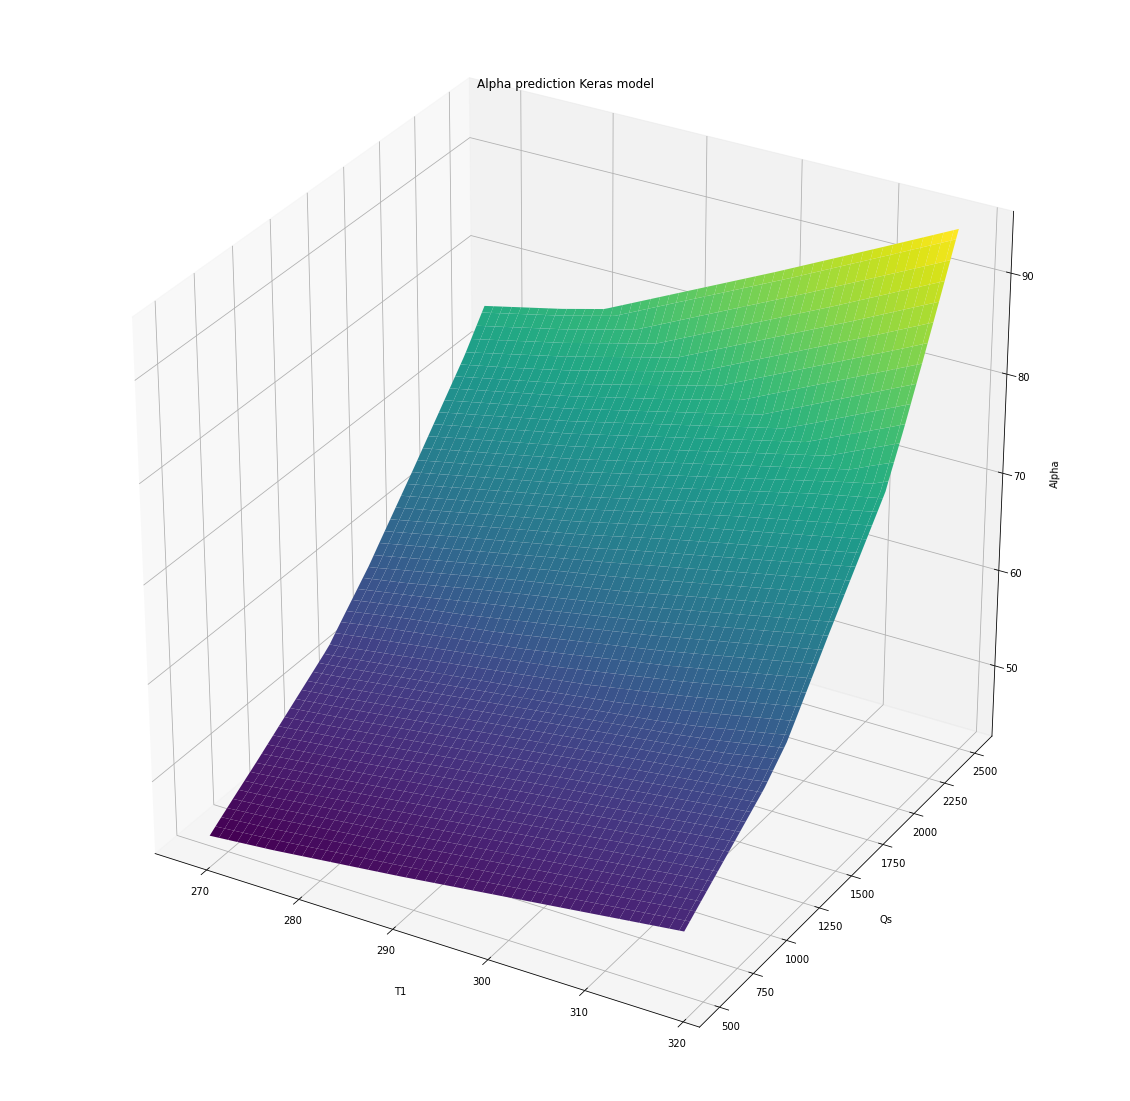

In [16]:
#plot predictions

plt.rcParams['figure.figsize'] = [20, 20] 
fig = plt.figure()

ax = plt.axes(projection='3d')
ax.zaxis.labelpad = 16
ax.xaxis.labelpad = 16
ax.yaxis.labelpad = 16
ax.plot_surface(X, Y, z, cmap='viridis', edgecolor='none')
#ax.plot_surface(math.log(X),math.log(Y), z, cmap='jet', edgecolor='none')
ax.set_title('Alpha prediction Keras model')
ax.set_xlabel('T1')
ax.set_ylabel('Qs')
ax.set_zlabel('Alpha')
plt.show()

In [17]:
# *** Task 2.3 a ***

#create input data array
# median values of input variables
# T12mean = 300.
# ga2mean = 0.2375
# qs2mean = 1625.

# T12med = 293. #actual medians
# ga2med = 0.25
# qs2med = 1500.

T12med = 293. #same as trained model
ga2med = 0.25
qs2med = 1250.

# T12med = 1.0
# ga2med = 1.0
# qs2med = 1.0

testxdata =  [[ 318.0/T12med , 0.0/ga2med , 500.0/qs2med ], [ 318.0/T12med , 0.0/ga2med , 1500.0/qs2med ]]
testxdata.append([ 318.0/T12med  , 0.0/ga2med , 2500.0/qs2med ])
testxdata.append([ 318.0/T12med  , 0.25/ga2med , 1500.0/qs2med ])
testxdata.append([ 318.0/T12med  , 0.5/ga2med , 500.0/qs2med ])
testxdata.append([ 318.0/T12med  , 0.5/ga2med , 1500.0/qs2med ])
testxdata.append([ 318.0/T12med  , 0.5/ga2med , 2500.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.0/ga2med , 1000.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.0/ga2med , 2000.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.25/ga2med , 1000.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.25/ga2med , 2000.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.5/ga2med , 1000.0/qs2med ])
testxdata.append([ 303.0/T12med  , 0.5/ga2med , 2000.0/qs2med ])
testxdata.append([ 288.0/T12med  , 0.0/ga2med , 500.0/qs2med ])
testxdata.append([ 288.0/T12med  , 0.0/ga2med , 2500.0/qs2med ])
testxdata.append([ 288.0/T12med  , 0.25/ga2med , 2500.0/qs2med ])
testxdata.append([ 288.0/T12med  , 0.5/ga2med , 1500.0/qs2med ])
testxdata.append([ 268.0/T12med  , 0.0/ga2med , 1500.0/qs2med ])
testxdata.append([ 268.0/T12med  , 0.25/ga2med , 2000.0/qs2med ])
testxdata.append([ 268.0/T12med  , 0.5/ga2med , 2500.0/qs2med ])

testxdata=np.array(testxdata)
print ('test data inputs: ')
print(testxdata)

# almed = 82.385  #actual values
# effmed = .4284

almed = 60.  #same as trained model
effmed = 0.4

testydata =  [[ 35.13/almed , 0.3808/effmed ], [ 47.46/almed , .3930/effmed]]
testydata.append([  73.12/almed ,  0.4061/effmed])
testydata.append([  66.34/almed ,  0.4098/effmed])
testydata.append([  63.09/almed ,  0.4154/effmed])
testydata.append([  85.23/almed ,   0.4197/effmed])
testydata.append([  131.32/almed ,  0.4242/effmed])
testydata.append([  38.99/almed ,  0.4012 /effmed])
testydata.append([  53.80/almed ,  0.4136/effmed])
testydata.append([  54.51/almed ,  0.4215/effmed])
testydata.append([  75.22/almed ,  0.4290/effmed])
testydata.append([  70.04/almed ,  0.4337/effmed])
testydata.append([  96.65/almed ,  0.4382/effmed])
testydata.append([  33.45/almed ,  0.4091/effmed])
testydata.append([  60.80/almed ,  0.4334 /effmed])
testydata.append([  85.044/almed ,  0.4477/effmed])
testydata.append([  77.56/almed ,  0.4516/effmed])
testydata.append([  40.68/almed ,  0.4383/effmed])
testydata.append([  65.24/almed ,   0.4628/effmed])
testydata.append([  98.23/almed ,  0.4760/effmed])

testydata=np.array(testydata)
print()
print ('test data outputs: ')
print(testydata)




test data inputs: 
[[1.08532423 0.         0.4       ]
 [1.08532423 0.         1.2       ]
 [1.08532423 0.         2.        ]
 [1.08532423 1.         1.2       ]
 [1.08532423 2.         0.4       ]
 [1.08532423 2.         1.2       ]
 [1.08532423 2.         2.        ]
 [1.03412969 0.         0.8       ]
 [1.03412969 0.         1.6       ]
 [1.03412969 1.         0.8       ]
 [1.03412969 1.         1.6       ]
 [1.03412969 2.         0.8       ]
 [1.03412969 2.         1.6       ]
 [0.98293515 0.         0.4       ]
 [0.98293515 0.         2.        ]
 [0.98293515 1.         2.        ]
 [0.98293515 2.         1.2       ]
 [0.91467577 0.         1.2       ]
 [0.91467577 1.         1.6       ]
 [0.91467577 2.         2.        ]]

test data outputs: 
[[0.5855     0.952     ]
 [0.791      0.9825    ]
 [1.21866667 1.01525   ]
 [1.10566667 1.0245    ]
 [1.0515     1.0385    ]
 [1.4205     1.04925   ]
 [2.18866667 1.0605    ]
 [0.64983333 1.003     ]
 [0.89666667 1.034     ]
 [0.9085     1

In [19]:
# predict and compare alphas

test23 = []
outpt23=[]

#first point (row [0])comparison of data and prediction
# put in a loop to print comparison for all data points

# for i in range
# test23 = [[ testxdata[0][0] , testxdata[0][1] , testxdata[0][2] ]]
# testarray23 = np.array(test23)
# outpt23 = model.predict(testarray23)
# print ('row [0] data:  T1= ', testxdata[0][0]*Tmed, ', gam= ', testxdata[0][1]*gamed, \
#     ', qsol= ', testxdata[0][2]*qsmed,', alpha= ', testydata[0][0]*almed,\
#     ',  predicted alpha = ', outpt23[0][0]*almed)

# #20th point (row [20])comparison of data and prediction
# test23 = [[ testxdata[20][0] , testxdata[20][1] , testxdata[20][2] ]]
# testarray = np.array(test23)
# outpt23 = model.predict(testarray)
# print ('row [20] data:  T1= ', testxdata[20][0]*Tmed, ', gam= ', testxdata[0][1]*gamed, \
#     ', qsol= ', testxdata[20][2]*qsmed,', alpha= ', testydata[20][0]*almed,\
#     ',  predicted alpha = ', outpt23[0][0]*almed)


pred23alpha = []

for i in range (20):
    test23 = [[ testxdata[i][0] , testxdata[i][1] , testxdata[i][2] ]]
    testarray23 = np.array(test23)
    outpt23 = model.predict(testarray23)
    outpt23 = outpt23*almed
    print ('T1= ', testxdata[i][0]*Tmed, ', gam= ', testxdata[i][1]*gamed, \
        ', qsol= ', testxdata[i][2]*qsmed,', alpha= ', testydata[i][0]*almed,\
        ',  predicted alpha = ', outpt23[0][0])
    pred23alpha.append(outpt23[0][0])
#     test23 = [[ testxdata[i][0] , testxdata[i][1] , testxdata[i][2] ]]
#     testarray = np.array(test23)
#     outpt23.append = model.predict(testarray)
    
print ()
print ('alpha predictions: ',pred23alpha)

T1=  318.0 , gam=  0.0 , qsol=  500.0 , alpha=  35.13 ,  predicted alpha =  34.632946
T1=  318.0 , gam=  0.0 , qsol=  1500.0 , alpha=  47.46 ,  predicted alpha =  45.95507
T1=  318.0 , gam=  0.0 , qsol=  2500.0 , alpha=  73.12 ,  predicted alpha =  69.25288
T1=  318.0 , gam=  0.25 , qsol=  1500.0 , alpha=  66.34 ,  predicted alpha =  64.286446
T1=  318.0 , gam=  0.5 , qsol=  500.0 , alpha=  63.09 ,  predicted alpha =  62.011906
T1=  318.0 , gam=  0.5 , qsol=  1500.0 , alpha=  85.23 ,  predicted alpha =  82.80767
T1=  318.0 , gam=  0.5 , qsol=  2500.0 , alpha=  131.32 ,  predicted alpha =  123.24181
T1=  303.0 , gam=  0.0 , qsol=  1000.0 , alpha=  38.99 ,  predicted alpha =  38.3037
T1=  303.0 , gam=  0.0 , qsol=  2000.0 , alpha=  53.8 ,  predicted alpha =  51.92473
T1=  303.0 , gam=  0.25 , qsol=  1000.0 , alpha=  54.51 ,  predicted alpha =  53.171013
T1=  303.0 , gam=  0.25 , qsol=  2000.0 , alpha=  75.22 ,  predicted alpha =  72.11636
T1=  303.0 , gam=  0.5 , qsol=  1000.0 , alpha=  

rms deviation =  2.8212601709880873
r value =  0.9992237987880013


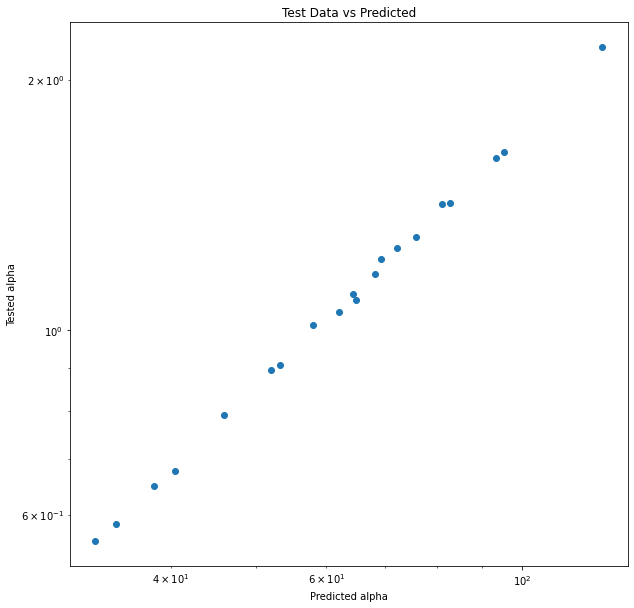

In [21]:
# *** plot test alpha vs pred alpha loglog ***
from scipy import stats

# *** RMS error ***


E23=[]
for i in range (len (testydata)):
    Err23 = (pred23alpha[i] - (testydata[i,0]*almed))*(pred23alpha[i] - (testydata[i,0]*almed))
    E23.append(Err23)
#     print ('predicted alpha: ', pred23alpha[i])
#     print ('tested alpha: ',testydata[i,0]*almed)
# print(E23)
rmsdev=((sum(E23)/len(E23)))**.5

# print ('sum: ', sum(E23))
print('rms deviation = ',rmsdev)

slope, intercept, r_value, p_value, std_err = stats.linregress(pred23alpha, testydata [:,0])
# print (slope, intercept, r_value)
print ('r value = ', r_value)

# Plot test values vs predictions
plt.rcParams['figure.figsize'] = [10, 10] 
plt.scatter(pred23alpha, testydata [:,0])
plt.title('Test Data vs Predicted')
plt.xlabel('Predicted alpha')
plt.ylabel('Tested alpha')
plt.loglog()
# plt.xlim(xmax = 1000, xmin = 10)
# plt.ylim(ymax = 1000, ymin = 10)

plt.show()

In [1]:
# *** Task 2.3 b ***
# Insert operation data

T12med = 293. #same as trained model
ga2med = 0.25
qs2med = 1250.

# T12med = 1.0
# ga2med = 1.0
# qs2med = 1.0

testxdatab =  [[ 287.0/T12med , 0.0/ga2med , 500.0/qs2med ], [ 295.0/T12med , 0.0/ga2med , 750.0/qs2med ]]
testxdatab.append([ 301.0/T12med  , 0.0/ga2med , 1000.0/qs2med ])
testxdatab.append([ 305.0/T12med  , 0.0/ga2med , 2450.0/qs2med ])
testxdatab.append([ 307.0/T12med  , 0.0/ga2med , 2600.0/qs2med ])
testxdatab.append([ 308.0/T12med  , 0.0/ga2med , 2400.0/qs2med ])
testxdatab.append([ 308.0/T12med  , 0.0/ga2med , 2100.0/qs2med ])
testxdatab.append([ 305.0/T12med  , 0.0/ga2med , 1800.0/qs2med ])
testxdatab.append([ 295.0/T12med  , 0.0/ga2med , 1300.0/qs2med ])
testxdatab.append([ 292.0/T12med  , 0.0/ga2med , 800.0/qs2med ])
testxdatab.append([ 295.0/T12med  , 0.0/ga2med , 250.0/qs2med ])

testxdatab.append([ 287.0/T12med , 0.5/ga2med , 500.0/qs2med ])
testxdatab.append([ 295.0/T12med , 0.5/ga2med , 750.0/qs2med ])
testxdatab.append([ 301.0/T12med  , 0.5/ga2med , 1000.0/qs2med ])
testxdatab.append([ 305.0/T12med  , 0.5/ga2med , 2450.0/qs2med ])
testxdatab.append([ 307.0/T12med  , 0.5/ga2med , 2600.0/qs2med ])
testxdatab.append([ 308.0/T12med  , 0.5/ga2med , 2400.0/qs2med ])
testxdatab.append([ 308.0/T12med  , 0.5/ga2med , 2100.0/qs2med ])
testxdatab.append([ 305.0/T12med  , 0.5/ga2med , 1800.0/qs2med ])
testxdatab.append([ 295.0/T12med  , 0.5/ga2med , 1300.0/qs2med ])
testxdatab.append([ 292.0/T12med  , 0.5/ga2med , 800.0/qs2med ])
testxdatab.append([ 295.0/T12med  , 0.5/ga2med , 250.0/qs2med ])


testxdatab=np.array(testxdatab)
print ('operation data inputs: ')
print(testxdatab)




NameError: ignored

In [ ]:
# Predict alpha values for operation

test23b = []
outpt23b=[]

pred23alphab = []
pred23effb = []
for i in range (22):
    test23b = [[ testxdatab[i][0] , testxdatab[i][1] , testxdatab[i][2] ]]
    testarray23b = np.array(test23b)
    outpt23b = model.predict(testarray23b)
    outpt23b = outpt23b
#     print ('T1= ', testxdatab[i][0]*Tmed, ', gam= ', testxdatab[i][1]*gamed, \
#         ', qsol= ', testxdatab[i][2]*qsmed,\
#         ',  predicted alpha = ', outpt23b[0][0]*almed)
    pred23alphab.append(outpt23b[0][0]*almed)
    pred23effb.append(outpt23b[0][1]*effmed)

alphazero = pred23alphab [0:11]
alphaptfive = pred23alphab [11:]
print('alpha predictions at gamma= 0: ', alphazero)
print('alpha predictions at gamma= 0.5: ', alphaptfive)


# print ('predicted efficiency: ',pred23effb)
print ()
for n in pred23alphab:
    print ('alpha predictions: ',n)

times = [*range(9,20)]
print(times)




In [ ]:
# plot alphas vs time

plt.figure(figsize=(12,9))
plt.scatter(times, alphazero, c='mediumblue', label='gamma = 0')
plt.scatter(times, alphaptfive, c='forestgreen', label='gamma = 0.5')
plt.legend()

plt.title('alpha vs. time of day')
plt.xlabel('time (24 hr)')
plt.ylabel('alpha')

#plt.loglog()
# plt.xlim(xmax = 5.5, xmin = 3.2)
# plt.ylim(ymax = 4.3, ymin = 3.2)

plt.show()